
# 03_postprocess_across_spatial_clean_refactored.ipynb

Clean refactored postprocessing notebook for **across-condition spatial AA**.

This version restores the original intended logic while keeping the newer conveniences:

- clustering uses **timecourse archetypes**: `sXC[:, k]`
- decoding uses **single-archetype reconstruction**:
  \[
  \hat X_k = sXC[:, k] \, S[k, :]
  \]
- brain interpretation uses **spatial coefficients**: `S[k, :]`

Included outputs:
- per-archetype spectral clustering with flexible cluster-number scan
- purity / balance / combined clustering score / ARI / NMI
- per-condition single-archetype decoding summaries
- decoding bar plots by condition
- joint ranking from clustering + decoding
- network-colored coefficient plots
- opacity-weighted coefficient plots
- selected-node network pie charts


In [13]:

LOAD_DIR = "msaa_flexible_outputs_npz"
K_VALUES = [5, 10]

TOP_N_REPORT = 3
CLUSTER_RANGE = range(2, 9)

# Clustering-score tuning
PURITY_WEIGHT = 3
BALANCE_WEIGHT = 1
PENALTY_MODE = "sqrt"   # "sqrt", "linear", or "none"

NFOLDS_DECODE = 2
NREPS_DECODE = 20
RNG_SEED = 42

COND_COLORS = {0: "purple", 1: "green", 2: "black"}
COND_NAME_COLORS = {"intact": "purple", "word": "green", "rest": "black"}

SCHAEFER_TXT = "data/pieman/raw/Schaefer2018_1000Parcels_7Networks_order.txt"
SCHAEFER_NII = "data/pieman/raw/Schaefer2018_1000Parcels_7Networks_order_FSLMNI152_2mm.nii.gz"
POSTERIOR_MAT = "data/pieman/raw/pieman_posterior_K700.mat"

OUTPUT_DIR = "postprocess_across_spatial_outputs"


In [14]:

%matplotlib inline
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.spatial.distance import cdist
from matplotlib.colors import ListedColormap, to_rgba
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

os.makedirs(OUTPUT_DIR, exist_ok=True)

try:
    import nibabel as nib
    from nilearn.input_data import NiftiMasker
    from nilearn import plotting as niplot
    NILEARN_AVAILABLE = True
except Exception:
    NILEARN_AVAILABLE = False
    print("nilearn / nibabel not available; brain plotting disabled.")

print("Ready.")


Ready.


In [15]:

def to_float_array(x):
    return np.array(x, dtype=float)

def load_msaa_npz(path):
    data = np.load(path, allow_pickle=True)
    results_subj = data["results_subj"].tolist()
    if isinstance(results_subj, np.ndarray):
        results_subj = results_subj.tolist()
    return {
        "K": int(data["K"]),
        "results_subj": results_subj,
        "condition_labels_str": data["condition_labels_str"].tolist(),
        "condition_codes": data["condition_codes"] if "condition_codes" in data else None,
        "condition_names": data["condition_names"].tolist() if "condition_names" in data else None,
    }

loaded = {}
for K in K_VALUES:
    path = os.path.join(LOAD_DIR, f"spatialAA_across_acrossCond_K{K}.npz")
    loaded[K] = load_msaa_npz(path)
    print("Loaded:", path)


Loaded: msaa_flexible_outputs_npz/spatialAA_across_acrossCond_K5.npz
Loaded: msaa_flexible_outputs_npz/spatialAA_across_acrossCond_K10.npz


In [16]:

posterior = loadmat(POSTERIOR_MAT)
centers = np.asarray(posterior['posterior']['centers'][0][0][0][0][0], dtype=float)
widths = np.asarray(list(posterior['posterior']['widths'][0][0][0][0][0][:, 0].T), dtype=float).ravel()

lookup_table = {
    'Vis': 'Visual',
    'SomMot': 'Somatomotor',
    'DorsAttn': 'Dorsal attention',
    'SalVentAttn': 'Ventral attention',
    'Limbic': 'Limbic',
    'Cont': 'Frontoparietal',
    'Default': 'Default mode'
}
network_colors = {
    'Visual': '#D7DF23',
    'Somatomotor': '#39B54A',
    'Dorsal attention': '#00A79D',
    'Ventral attention': '#27AAE1',
    'Limbic': '#1C75BC',
    'Frontoparietal': '#92278F',
    'Default mode': '#EE2A7B'
}
colors = ['#888888'] + [v for _, v in network_colors.items()]
network_cmap = ListedColormap(colors, N=len(colors) * 2, name='networks')
network_codes = {k: i + 1 for i, k in enumerate(lookup_table.values())}
print(network_codes)


{'Visual': 1, 'Somatomotor': 2, 'Dorsal attention': 3, 'Ventral attention': 4, 'Limbic': 5, 'Frontoparietal': 6, 'Default mode': 7}


In [17]:

def nii2cmu(nifti_file, mask_file=None):
    def fullfact(dims):
        vals = np.asmatrix(range(1, dims[0] + 1)).T
        if len(dims) == 1:
            return vals
        aftervals = np.asmatrix(fullfact(dims[1:]))
        inds = np.asmatrix(np.zeros((np.prod(dims), len(dims))))
        row = 0
        for i in range(aftervals.shape[0]):
            inds[row:(row + len(vals)), 0] = vals
            inds[row:(row + len(vals)), 1:] = np.tile(aftervals[i, :], (len(vals), 1))
            row += len(vals)
        return inds

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        img = nib.load(nifti_file) if type(nifti_file) == str else nifti_file
        mask = NiftiMasker(mask_strategy='background')
        mask.fit(nifti_file if mask_file is None else mask_file)

    S = img.get_sform()
    Y = np.float32(mask.transform(nifti_file)).copy()
    vmask = np.nonzero(np.array(np.reshape(mask.mask_img_.dataobj, (1, np.prod(mask.mask_img_.shape)), order='C')))[1]
    vox_coords = fullfact(img.shape[0:3])[vmask, ::-1] - 1
    R = np.array(np.dot(vox_coords, S[0:3, 0:3])) + S[:3, 3]
    return {'Y': Y, 'R': R}

def rbf(R, center, width):
    return np.exp(-np.sum((R - center) ** 2, axis=1) / width)

def node_labels(centers, widths, networks_cmu):
    labels = []
    for c, w in zip(centers, widths):
        r = rbf(networks_cmu['R'], c, w)
        label_weights = [sum(r[networks_cmu['Y'].ravel() == i]) for i in range(1, len(network_codes) + 1)]
        labels.append(np.argmax(label_weights) + 1)
    return pd.DataFrame({
        'code': labels,
        'Network': [list(lookup_table.values())[i - 1] for i in labels]
    })

key = pd.read_csv(
    SCHAEFER_TXT,
    sep='\t',
    header=None,
    names=['id', 'name', 'x', 'y', 'z', 't']
).drop('t', axis=1)
key['study'] = key['name'].apply(lambda x: x.split('_')[0])
key['hemisphere'] = key['name'].apply(lambda x: x.split('_')[1][0])
key['network'] = key['name'].apply(lambda x: x.split('_')[2])
key.drop('name', axis=1, inplace=True)
key['network'] = key['network'].apply(lambda x: lookup_table[x])
key['code'] = key['network'].apply(lambda x: network_codes[x])
key.set_index('id', inplace=True)
key.loc[0, 'code'] = 0

networks_cmu = nii2cmu(SCHAEFER_NII)
networks_cmu['Y'] = np.atleast_2d(np.array([key.loc[i, 'code'] for i in networks_cmu['Y']]).astype(float))
node_codes_template = node_labels(centers, widths, networks_cmu)
display(node_codes_template.head())


,code,Network
0,4,Ventral attention
1,3,Dorsal attention
2,1,Visual
3,6,Frontoparietal
4,4,Ventral attention


In [18]:

def decoder(corrs):
    out = pd.DataFrame({'rank': [0.0], 'accuracy': [0.0], 'error': [0.0]})
    T = corrs.shape[0]
    for t in range(T):
        decoded_ind = int(np.argmax(corrs[t, :]))
        out.loc[0, 'error'] += np.mean(np.abs(decoded_ind - t)) / T
        out.loc[0, 'accuracy'] += (decoded_ind == t)
        out.loc[0, 'rank'] += np.mean((corrs[t, :] <= corrs[t, t]).astype(int))
    out['error'] /= T
    out['accuracy'] /= T
    out['rank'] /= T
    return out

def get_xval_assignments(ndata, nfolds, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    group_assignments = np.zeros(ndata, dtype=int)
    groupsize = int(np.ceil(ndata / nfolds))
    for i in range(1, nfolds):
        inds = np.arange(i * groupsize, min((i + 1) * groupsize, ndata))
        group_assignments[inds] = i
    rng.shuffle(group_assignments)
    return group_assignments

def build_single_archetype_recon_stack(subjects, k):
    Xhats = []
    for sub in subjects:
        sXC = np.asarray(sub["sXC"], dtype=float)
        S = np.asarray(sub["S"], dtype=float)
        Xhat = sXC[:, [k]] @ S[[k], :]
        Xhat = (Xhat - Xhat.mean(axis=0, keepdims=True)) / (Xhat.std(axis=0, keepdims=True) + 1e-8)
        Xhats.append(Xhat)
    return np.stack(Xhats, axis=0)

def run_timepoint_decoding(recon_stack, nfolds=2, nreps=20, seed=42):
    N, T, V = recon_stack.shape
    rng = np.random.default_rng(seed)
    all_results = []
    for rep in range(nreps):
        fold_ids = get_xval_assignments(N, nfolds, rng=rng)
        for i in range(nfolds):
            in_mask = (fold_ids == i)
            out_mask = ~in_mask
            in_mean = recon_stack[in_mask].mean(axis=0)
            out_mean = recon_stack[out_mask].mean(axis=0)
            corrs = 1.0 - cdist(in_mean, out_mean, metric='correlation')
            res = decoder(corrs)
            res["rep"] = rep
            res["fold"] = i
            all_results.append(res)
    return pd.concat(all_results, ignore_index=True)

def single_archetype_decoding_by_condition(results_subj, condition_labels_str, k, nfolds=2, nreps=20, seed=42):
    rows = []
    for cond_name in np.unique(condition_labels_str):
        idx = np.where(np.asarray(condition_labels_str) == cond_name)[0]
        sub_cond = [results_subj[i] for i in idx]
        recon_stack = build_single_archetype_recon_stack(sub_cond, k)
        res = run_timepoint_decoding(recon_stack, nfolds=nfolds, nreps=nreps, seed=seed)
        res["condition"] = cond_name
        res["archetype"] = k
        rows.append(res)
    return pd.concat(rows, ignore_index=True)

def summarize_single_archetype_decoding(results_subj, condition_labels_str, k, nfolds=2, nreps=20, seed=42):
    dec_df = single_archetype_decoding_by_condition(results_subj, condition_labels_str, k, nfolds=nfolds, nreps=nreps, seed=seed)
    summary = dec_df.groupby("condition")["accuracy"].agg(["mean", "std", "count"]).reset_index()
    summary["sem"] = summary["std"] / np.sqrt(summary["count"].clip(lower=1))
    summary["archetype"] = k
    overall = dec_df["accuracy"].mean()
    return dec_df, summary, overall


In [19]:

def purity_score(y_cluster, y_class):
    y_cluster = np.asarray(y_cluster)
    y_class = np.asarray(y_class)
    total = 0
    for c in np.unique(y_cluster):
        mask = (y_cluster == c)
        _, counts = np.unique(y_class[mask], return_counts=True)
        total += counts.max()
    return total / len(y_cluster)

def equal_size_balance(labels):
    labels = np.asarray(labels)
    _, counts = np.unique(labels, return_counts=True)
    N = counts.sum()
    k = len(counts)
    ideal = N / k
    imbalance = np.sum(np.abs(counts - ideal)) / (2 * N)
    return float(1.0 - imbalance)

def cluster_count_penalty(n_clusters, mode="sqrt"):
    if mode == "linear":
        return 1.0 / n_clusters
    elif mode == "sqrt":
        return 1.0 / np.sqrt(n_clusters)
    elif mode == "none":
        return 1.0
    else:
        raise ValueError("mode must be 'linear', 'sqrt', or 'none'")

def score_clustering_solution(labels, cond, purity_weight=1.5, balance_weight=1.0, penalty_mode="sqrt"):
    labels = np.asarray(labels)
    cond = np.asarray(cond)
    n_clusters = len(np.unique(labels))
    purity = purity_score(labels, cond)
    balance = equal_size_balance(labels)
    penalty = cluster_count_penalty(n_clusters, mode=penalty_mode)
    score = (purity ** purity_weight) * (balance ** balance_weight) * penalty
    _, counts = np.unique(labels, return_counts=True)
    return {
        "n_clusters": n_clusters,
        "purity": purity,
        "balance": balance,
        "penalty": penalty,
        "score": score,
        "cluster_sizes": counts.tolist(),
    }

def get_timecourse_archetype_subject_matrix(results_subj, k, eps=1e-8):
    Xk = np.stack([np.asarray(sub["sXC"], dtype=float)[:, k] for sub in results_subj], axis=0)
    mu = Xk.mean(axis=1, keepdims=True)
    sd = Xk.std(axis=1, keepdims=True)
    Xk = (Xk - mu) / (sd + eps)
    return np.nan_to_num(Xk, nan=0.0, posinf=0.0, neginf=0.0)

def reorder_by_labels_and_within_similarity(sim, labels):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)
    order = []
    for lab in unique_labels:
        idx = np.where(labels == lab)[0]
        sub_sim = sim[np.ix_(idx, idx)]
        sub_order = idx[np.argsort(-sub_sim.mean(axis=1))]
        order.extend(sub_order.tolist())
    order = np.array(order)
    labels_sorted = labels[order]
    boundaries = np.where(np.asarray(labels_sorted[1:]) != np.asarray(labels_sorted[:-1]))[0] + 1
    return order, labels_sorted, boundaries

def make_result_from_labels(sim, labels, cond):
    order, labels_sorted, boundaries = reorder_by_labels_and_within_similarity(sim, labels)
    return {
        "sim": sim,
        "sim_sorted": sim[np.ix_(order, order)],
        "order": order,
        "labels": labels,
        "labels_sorted": labels_sorted,
        "cond_sorted": np.asarray(cond)[order],
        "boundaries": boundaries,
        "purity": purity_score(labels, cond),
        "ari": adjusted_rand_score(cond, labels),
        "nmi": normalized_mutual_info_score(cond, labels),
    }

def cluster_spectral(sim, cond, n_clusters=3, assign_labels="kmeans", random_state=0):
    sim = np.asarray(sim, dtype=float)
    sim = np.nan_to_num(sim, nan=0.0, posinf=0.0, neginf=0.0)
    sim = np.clip(sim, -1.0, 1.0)
    aff = (sim + 1.0) / 2.0
    np.fill_diagonal(aff, 1.0)
    model = SpectralClustering(
        n_clusters=n_clusters,
        affinity="precomputed",
        assign_labels=assign_labels,
        random_state=random_state,
    )
    labels = model.fit_predict(aff) + 1
    return make_result_from_labels(sim, labels, cond)

def scan_spectral_cluster_numbers_for_archetype(Xk, sim, cond, cluster_range=range(2, 9), purity_weight=1.5, balance_weight=1.0, penalty_mode="sqrt", random_state=0):
    rows = []
    results = {}
    for n_clusters in cluster_range:
        res = cluster_spectral(sim=sim, cond=cond, n_clusters=n_clusters, assign_labels="kmeans", random_state=random_state)
        scored = score_clustering_solution(
            labels=res["labels"],
            cond=cond,
            purity_weight=purity_weight,
            balance_weight=balance_weight,
            penalty_mode=penalty_mode
        )
        rows.append({
            "n_clusters": n_clusters,
            "purity": scored["purity"],
            "balance": scored["balance"],
            "penalty": scored["penalty"],
            "score": scored["score"],
            "ari": res["ari"],
            "nmi": res["nmi"],
            "cluster_sizes": scored["cluster_sizes"],
        })
        results[n_clusters] = res
    return pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True), results


In [20]:

def plot_decoding_bar_from_summary(dec_summary, K, k):
    plot_df = dec_summary.copy()
    plt.figure(figsize=(5,4))
    plt.bar(
        plot_df["condition"],
        plot_df["mean"],
        yerr=plot_df["sem"],
        color=[COND_NAME_COLORS.get(c, "gray") for c in plot_df["condition"]],
        capsize=4
    )
    plt.ylabel("Decoding accuracy")
    plt.title(f"K={K} | archetype {k} | single-archetype decoding")
    plt.tight_layout()
    plt.show()

def plot_cluster_scan_metrics(scan_df, archetype_k=None):
    plot_df = scan_df.sort_values("n_clusters")
    plt.figure(figsize=(8, 5))
    plt.plot(plot_df["n_clusters"], plot_df["purity"], marker="o", label="Purity")
    plt.plot(plot_df["n_clusters"], plot_df["balance"], marker="o", label="Balance")
    plt.plot(plot_df["n_clusters"], plot_df["score"], marker="o", label="Combined score")
    plt.xlabel("Number of clusters")
    plt.ylabel("Score")
    title = "Flexible spectral cluster-number scan"
    if archetype_k is not None:
        title += f" | archetype {archetype_k}"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_clustered_similarity(result, cond_colors=None, title="", show_subject_ids=True):
    if cond_colors is None:
        cond_colors = {0: "purple", 1: "green", 2: "black"}
    order = result["order"]
    cond_sorted = result["cond_sorted"]
    xticklabels = (order + 1) if show_subject_ids else False
    yticklabels = (order + 1) if show_subject_ids else False
    plt.figure(figsize=(7, 6))
    ax = sns.heatmap(
        result["sim_sorted"],
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        square=True,
        xticklabels=xticklabels,
        yticklabels=yticklabels,
        cbar_kws={"label": "subject correlation of archetype timecourses"},
    )
    if show_subject_ids:
        tick_colors = [cond_colors.get(int(c), "gray") for c in cond_sorted]
        for tick_label, color in zip(ax.get_xticklabels(), tick_colors):
            tick_label.set_color(color)
            tick_label.set_rotation(90)
            tick_label.set_fontsize(8)
        for tick_label, color in zip(ax.get_yticklabels(), tick_colors):
            tick_label.set_color(color)
            tick_label.set_fontsize(8)
    for b in result["boundaries"]:
        ax.axhline(b, color="black", linewidth=2)
        ax.axvline(b, color="black", linewidth=2)
    plt.title(f"{title}\nPur={result['purity']:.2f}, ARI={result['ari']:.2f}, NMI={result['nmi']:.2f}")
    plt.tight_layout()
    plt.show()

def coefficient_to_alpha(weights, keep_mask, alpha_min=0.15, alpha_max=1.0):
    w = np.asarray(weights, dtype=float).ravel()
    w = np.nan_to_num(w, nan=0.0, posinf=0.0, neginf=0.0)
    wk = w[keep_mask]
    if len(wk) == 0:
        return np.array([])
    wmin, wmax = wk.min(), wk.max()
    if np.isclose(wmax, wmin):
        return np.full(len(wk), alpha_max)
    scaled = (wk - wmin) / (wmax - wmin)
    return alpha_min + (alpha_max - alpha_min) * scaled

def plot_network_colored_spatial_coeff_map(results_subj, k, title="", display_mode="lyrz", node_size=10, thr_frac=0.30, use_opacity=False, alpha_min=0.15, alpha_max=1.0):
    if not NILEARN_AVAILABLE:
        print("nilearn not available; skipping.")
        return None, None, None
    coeffs = np.stack([np.asarray(sub["S"], dtype=float)[k, :] for sub in results_subj], axis=0)
    weights = np.nan_to_num(coeffs.mean(axis=0), nan=0.0, posinf=0.0, neginf=0.0)
    wmax = np.max(weights)
    if wmax <= 0:
        print(f"Skipping archetype {k}: non-positive weights")
        return None, None, None
    keep = weights >= (thr_frac * wmax)
    centers_sel = centers[keep]
    node_codes_local = node_labels(centers, widths, networks_cmu)
    codes_sel = node_codes_local.loc[keep, 'code'].to_numpy()
    if use_opacity:
        alphas = coefficient_to_alpha(weights, keep, alpha_min=alpha_min, alpha_max=alpha_max)
        node_colors = []
        for code, alpha in zip(codes_sel, alphas):
            base = to_rgba(colors[code])
            node_colors.append((base[0], base[1], base[2], float(alpha)))
    else:
        node_colors = [colors[i] for i in codes_sel]
    display = niplot.plot_connectome(
        np.eye(centers_sel.shape[0]),
        centers_sel,
        node_size=node_size,
        node_color=node_colors,
        display_mode=display_mode,
        title=title,
    )
    plt.show()
    plt.clf()
    return display, node_codes_local, keep

def plot_network_pie_for_selected_nodes(node_codes_local, keep_mask, title="Network composition", out_file=None):
    selected = node_codes_local.loc[keep_mask].copy()
    counts = selected["Network"].value_counts().reindex(list(network_colors.keys()), fill_value=0)
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    pie_colors = [network_colors[name] for name in counts.index]
    ax.pie(
        counts.values,
        labels=counts.index,
        colors=pie_colors,
        autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
        startangle=90,
        counterclock=False,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    if out_file is not None:
        fig.savefig(out_file, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return counts


In [21]:

def analyze_archetypes_for_K(cur, K_value, cluster_range=range(2, 9), purity_weight=1.5, balance_weight=1.0, penalty_mode="sqrt", nfolds=2, nreps=20, seed=42):
    results_subj = cur["results_subj"]
    condition_labels_str = np.array(cur["condition_labels_str"])
    cond = cur["condition_codes"]
    n_archetypes = np.asarray(results_subj[0]["sXC"]).shape[1]
    rows = []
    cluster_store = {}
    decoding_store = {}

    for k in range(n_archetypes):
        Xk = get_timecourse_archetype_subject_matrix(results_subj, k=k)
        sim = np.corrcoef(Xk)
        sim = np.nan_to_num(sim, nan=0.0, posinf=0.0, neginf=0.0)
        sim = np.clip(sim, -1.0, 1.0)
        np.fill_diagonal(sim, 1.0)

        scan_df, scan_results = scan_spectral_cluster_numbers_for_archetype(
            Xk=Xk,
            sim=sim,
            cond=cond,
            cluster_range=cluster_range,
            purity_weight=purity_weight,
            balance_weight=balance_weight,
            penalty_mode=penalty_mode,
            random_state=0
        )

        best_cluster_row = scan_df.iloc[0]
        dec_df, dec_summary, dec_overall = summarize_single_archetype_decoding(
            results_subj,
            condition_labels_str,
            k,
            nfolds=nfolds,
            nreps=nreps,
            seed=seed,
        )

        row = {
            "K": K_value,
            "archetype": k,
            "best_n_clusters": int(best_cluster_row["n_clusters"]),
            "purity": float(best_cluster_row["purity"]),
            "balance": float(best_cluster_row["balance"]),
            "cluster_score": float(best_cluster_row["score"]),
            "ari": float(best_cluster_row["ari"]),
            "nmi": float(best_cluster_row["nmi"]),
            "cluster_sizes": best_cluster_row["cluster_sizes"],
            "decode_accuracy_overall": float(dec_overall),
        }
        for _, r in dec_summary.iterrows():
            cond_name = r["condition"]
            row[f"decode_{cond_name}"] = float(r["mean"])
            row[f"decode_{cond_name}_sem"] = float(r["sem"])

        rows.append(row)
        cluster_store[k] = {"scan_df": scan_df, "scan_results": scan_results}
        decoding_store[k] = {"dec_df": dec_df, "dec_summary": dec_summary}

    summary_df = pd.DataFrame(rows)
    summary_df["cluster_rank"] = summary_df["cluster_score"].rank(ascending=False, method="average")
    summary_df["decode_rank"] = summary_df["decode_accuracy_overall"].rank(ascending=False, method="average")
    summary_df["joint_rank_score"] = -(summary_df["cluster_rank"] + summary_df["decode_rank"])
    return {"summary_df": summary_df, "cluster_store": cluster_store, "decoding_store": decoding_store}

all_archetype_analysis = {}
all_rows = []
for K in K_VALUES:
    print(f"\n===== Analyzing archetypes for K={K} =====")
    cur = loaded[K]
    res = analyze_archetypes_for_K(
        cur,
        K_value=K,
        cluster_range=CLUSTER_RANGE,
        purity_weight=PURITY_WEIGHT,
        balance_weight=BALANCE_WEIGHT,
        penalty_mode=PENALTY_MODE,
        nfolds=NFOLDS_DECODE,
        nreps=NREPS_DECODE,
        seed=RNG_SEED
    )
    all_archetype_analysis[K] = res
    all_rows.append(res["summary_df"])
    display(
        res["summary_df"].sort_values(
            ["joint_rank_score", "cluster_score", "decode_accuracy_overall"],
            ascending=[False, False, False]
        ).head(10)
    )

archetype_summary_allK_df = pd.concat(all_rows, ignore_index=True)



===== Analyzing archetypes for K=5 =====


,K,archetype,best_n_clusters,purity,balance,cluster_score,ari,nmi,cluster_sizes,decode_accuracy_overall,decode_intact,decode_intact_sem,decode_rest,decode_rest_sem,decode_word,decode_word_sem,cluster_rank,decode_rank,joint_rank_score
1,5,1,2,0.611111,1.000000,0.161378,0.316587,0.327916,"[54, 54]",0.007111,0.007000,0.000443,0.006917,0.000658,0.007417,0.000553,1.0,2.0,-3.0
2,5,2,2,0.620370,0.907407,0.153194,0.378226,0.388352,"[44, 64]",0.007139,0.008583,0.000545,0.006583,0.000822,0.006250,0.000645,2.0,1.0,-3.0
0,5,0,4,0.685185,0.944444,0.151904,0.288749,0.289787,"[30, 30, 24, 24]",0.005611,0.007583,0.000560,0.002250,0.000437,0.007000,0.000629,3.0,4.0,-7.0
3,5,3,8,0.574074,0.916667,0.061315,0.050975,0.126547,"[13, 8, 18, 13, 14, 15, 11, 16]",0.006278,0.006750,0.000454,0.004917,0.000597,0.007167,0.000579,5.0,3.0,-8.0
4,5,4,4,0.546296,0.898148,0.073215,0.100637,0.136357,"[29, 36, 19, 24]",0.005556,0.007250,0.000571,0.004000,0.000465,0.005417,0.000605,4.0,5.0,-9.0



===== Analyzing archetypes for K=10 =====


/opt/homebrew/anaconda3/envs/archs/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/anaconda3/envs/archs/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,K,archetype,best_n_clusters,purity,balance,cluster_score,ari,nmi,cluster_sizes,decode_accuracy_overall,decode_intact,decode_intact_sem,decode_rest,decode_rest_sem,decode_word,decode_word_sem,cluster_rank,decode_rank,joint_rank_score
3,10,3,2,0.629630,0.925926,0.163424,0.430697,0.466848,"[62, 46]",0.006694,0.008750,0.000568,0.004750,0.000532,0.006583,0.000701,2.0,4.0,-6.0
5,10,5,2,0.592593,0.972222,0.143060,0.276045,0.272212,"[57, 51]",0.006694,0.007500,0.000530,0.004500,0.000567,0.008083,0.000607,3.0,3.0,-6.0
2,10,2,2,0.583333,0.990741,0.139058,0.260072,0.261785,"[53, 55]",0.006750,0.007917,0.000502,0.004000,0.000575,0.008333,0.000597,4.0,2.0,-6.0
1,10,1,3,0.740741,0.944444,0.221623,0.381847,0.355929,"[36, 42, 30]",0.005806,0.008083,0.000595,0.002917,0.000381,0.006417,0.000420,1.0,7.0,-8.0
4,10,4,2,0.398148,0.944444,0.042150,0.005571,0.015369,"[60, 48]",0.007667,0.008500,0.000546,0.005833,0.000517,0.008667,0.000474,9.0,1.0,-10.0
7,10,7,3,0.592593,0.879630,0.105684,0.153132,0.144413,"[45, 40, 23]",0.005500,0.006833,0.000546,0.004000,0.000562,0.005667,0.000575,5.0,8.0,-13.0
6,10,6,6,0.537037,0.916667,0.057963,0.054006,0.090492,"[15, 21, 15, 24, 15, 18]",0.005944,0.005917,0.000499,0.005583,0.000498,0.006333,0.000570,7.0,6.0,-13.0
9,10,9,2,0.453704,0.990741,0.065428,0.046184,0.049776,"[55, 53]",0.004806,0.005417,0.000617,0.004667,0.000652,0.004333,0.000550,6.0,9.0,-15.0
0,10,0,4,0.435185,0.870370,0.035867,0.011077,0.039073,"[25, 27, 41, 15]",0.006056,0.007667,0.000862,0.004917,0.000664,0.005583,0.000669,10.0,5.0,-15.0
8,10,8,5,0.500000,0.911111,0.050933,0.027577,0.053812,"[23, 23, 28, 12, 22]",0.004750,0.005083,0.000706,0.003000,0.000410,0.006167,0.000528,8.0,10.0,-18.0


In [22]:

display(archetype_summary_allK_df.sort_values(["K", "joint_rank_score"], ascending=[True, False]))

best_archetype_rows = []
for K in K_VALUES:
    df = all_archetype_analysis[K]["summary_df"].copy()
    best_row = df.sort_values("joint_rank_score", ascending=False).iloc[0]
    best_archetype_rows.append(best_row)

best_archetypes_by_K_df = pd.DataFrame(best_archetype_rows)
display(best_archetypes_by_K_df)


,K,archetype,best_n_clusters,purity,balance,cluster_score,ari,nmi,cluster_sizes,decode_accuracy_overall,decode_intact,decode_intact_sem,decode_rest,decode_rest_sem,decode_word,decode_word_sem,cluster_rank,decode_rank,joint_rank_score
1,5,1,2,0.611111,1.000000,0.161378,0.316587,0.327916,"[54, 54]",0.007111,0.007000,0.000443,0.006917,0.000658,0.007417,0.000553,1.0,2.0,-3.0
2,5,2,2,0.620370,0.907407,0.153194,0.378226,0.388352,"[44, 64]",0.007139,0.008583,0.000545,0.006583,0.000822,0.006250,0.000645,2.0,1.0,-3.0
0,5,0,4,0.685185,0.944444,0.151904,0.288749,0.289787,"[30, 30, 24, 24]",0.005611,0.007583,0.000560,0.002250,0.000437,0.007000,0.000629,3.0,4.0,-7.0
3,5,3,8,0.574074,0.916667,0.061315,0.050975,0.126547,"[13, 8, 18, 13, 14, 15, 11, 16]",0.006278,0.006750,0.000454,0.004917,0.000597,0.007167,0.000579,5.0,3.0,-8.0
4,5,4,4,0.546296,0.898148,0.073215,0.100637,0.136357,"[29, 36, 19, 24]",0.005556,0.007250,0.000571,0.004000,0.000465,0.005417,0.000605,4.0,5.0,-9.0
7,10,2,2,0.583333,0.990741,0.139058,0.260072,0.261785,"[53, 55]",0.006750,0.007917,0.000502,0.004000,0.000575,0.008333,0.000597,4.0,2.0,-6.0
8,10,3,2,0.629630,0.925926,0.163424,0.430697,0.466848,"[62, 46]",0.006694,0.008750,0.000568,0.004750,0.000532,0.006583,0.000701,2.0,4.0,-6.0
10,10,5,2,0.592593,0.972222,0.143060,0.276045,0.272212,"[57, 51]",0.006694,0.007500,0.000530,0.004500,0.000567,0.008083,0.000607,3.0,3.0,-6.0
6,10,1,3,0.740741,0.944444,0.221623,0.381847,0.355929,"[36, 42, 30]",0.005806,0.008083,0.000595,0.002917,0.000381,0.006417,0.000420,1.0,7.0,-8.0
9,10,4,2,0.398148,0.944444,0.042150,0.005571,0.015369,"[60, 48]",0.007667,0.008500,0.000546,0.005833,0.000517,0.008667,0.000474,9.0,1.0,-10.0


,K,archetype,best_n_clusters,purity,balance,cluster_score,ari,nmi,cluster_sizes,decode_accuracy_overall,decode_intact,decode_intact_sem,decode_rest,decode_rest_sem,decode_word,decode_word_sem,cluster_rank,decode_rank,joint_rank_score
1,5,1,2,0.611111,1.000000,0.161378,0.316587,0.327916,"[54, 54]",0.007111,0.007000,0.000443,0.006917,0.000658,0.007417,0.000553,1.0,2.0,-3.0
2,10,2,2,0.583333,0.990741,0.139058,0.260072,0.261785,"[53, 55]",0.006750,0.007917,0.000502,0.004000,0.000575,0.008333,0.000597,4.0,2.0,-6.0



Detailed plots for K=5

K=5 | archetype=1


,K,archetype,best_n_clusters,purity,balance,cluster_score,ari,nmi,cluster_sizes,decode_accuracy_overall,decode_intact,decode_intact_sem,decode_rest,decode_rest_sem,decode_word,decode_word_sem,cluster_rank,decode_rank,joint_rank_score
1,5,1,2,0.611111,1.0,0.161378,0.316587,0.327916,"[54, 54]",0.007111,0.007,0.000443,0.006917,0.000658,0.007417,0.000553,1.0,2.0,-3.0


,condition,mean,std,count,sem,archetype
0,intact,0.007000,0.002804,40,0.000443,1
1,rest,0.006917,0.004161,40,0.000658,1
2,word,0.007417,0.003499,40,0.000553,1


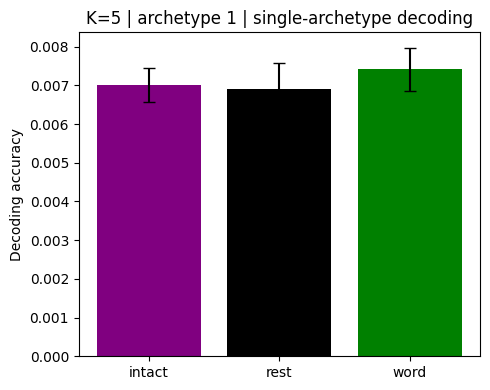

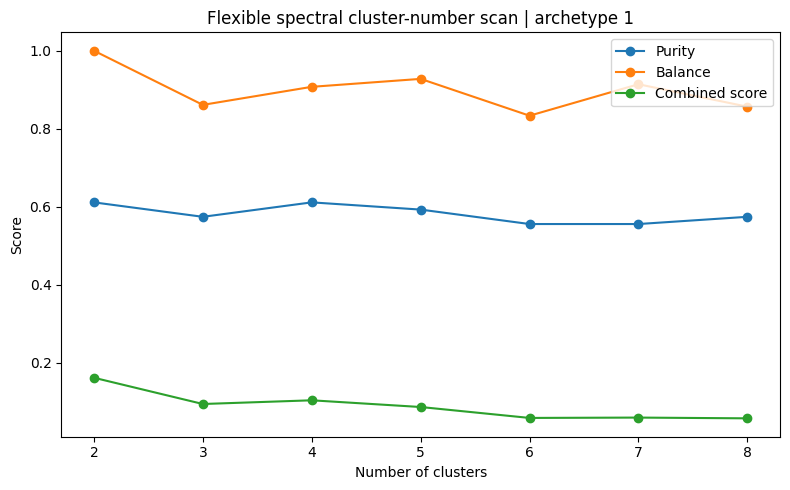

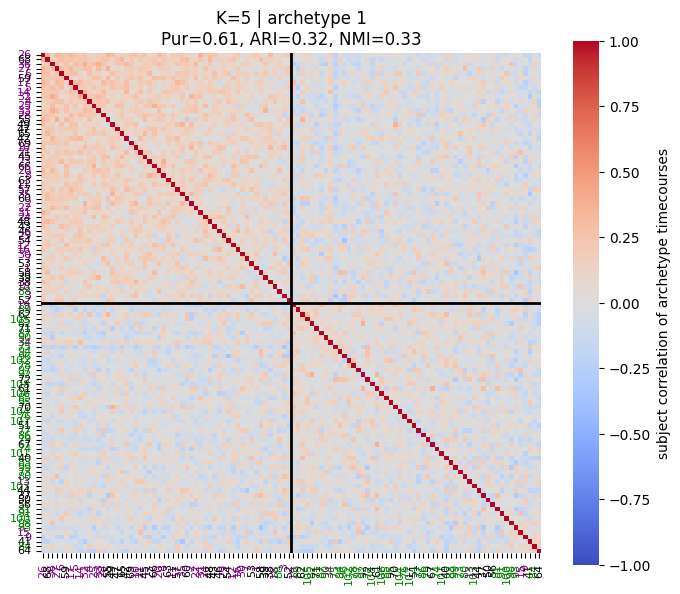

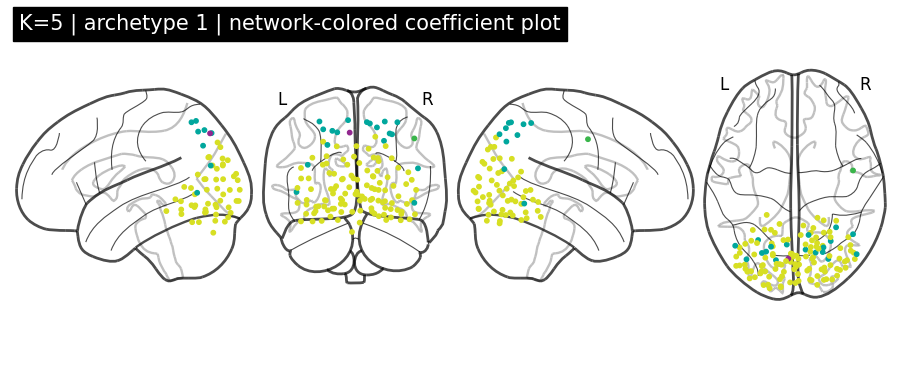

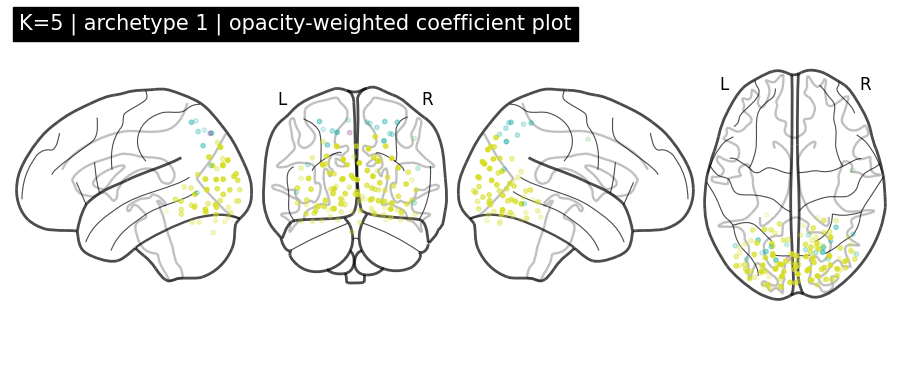

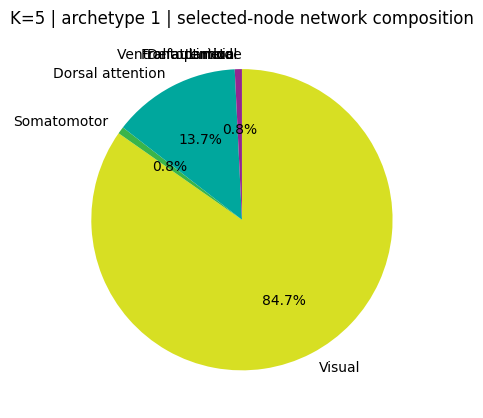


K=5 | archetype=2


,K,archetype,best_n_clusters,purity,balance,cluster_score,ari,nmi,cluster_sizes,decode_accuracy_overall,decode_intact,decode_intact_sem,decode_rest,decode_rest_sem,decode_word,decode_word_sem,cluster_rank,decode_rank,joint_rank_score
2,5,2,2,0.62037,0.907407,0.153194,0.378226,0.388352,"[44, 64]",0.007139,0.008583,0.000545,0.006583,0.000822,0.00625,0.000645,2.0,1.0,-3.0


,condition,mean,std,count,sem,archetype
0,intact,0.008583,0.003450,40,0.000545,2
1,rest,0.006583,0.005202,40,0.000822,2
2,word,0.006250,0.004078,40,0.000645,2


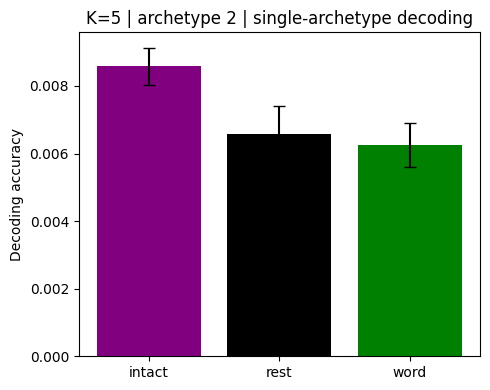

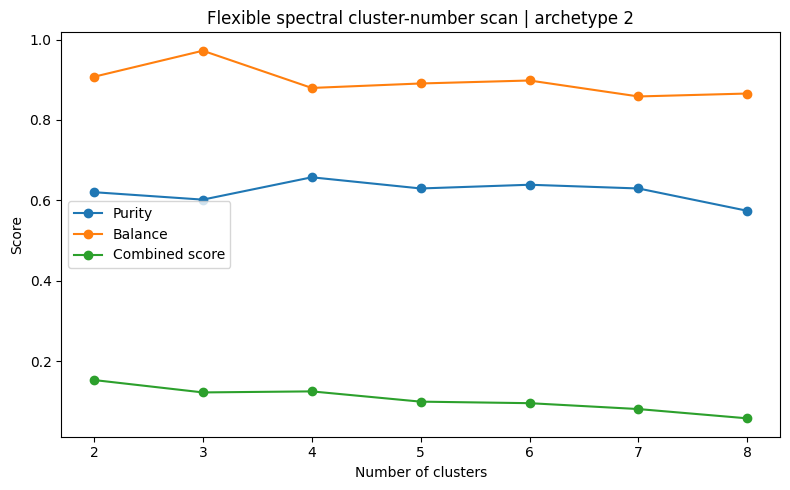

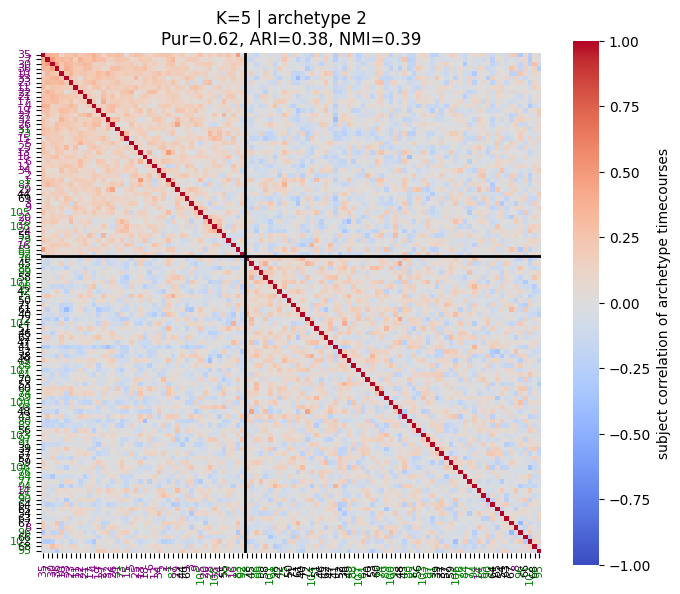

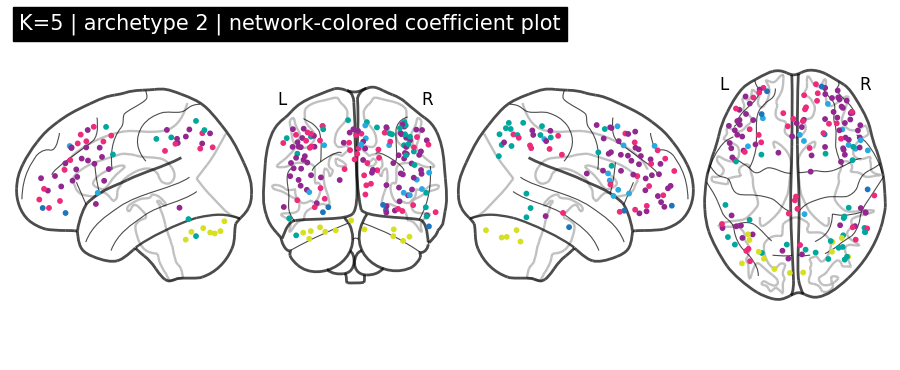

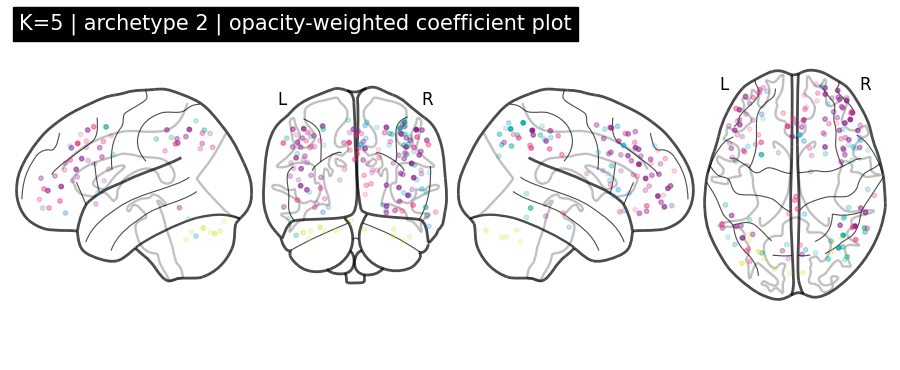

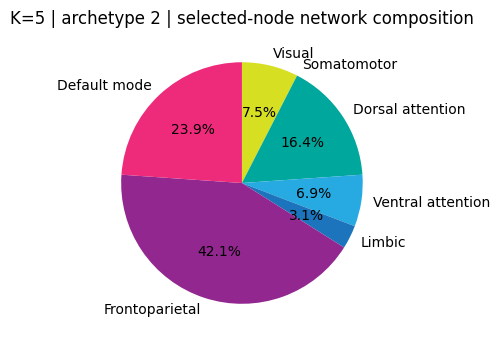


K=5 | archetype=0


,K,archetype,best_n_clusters,purity,balance,cluster_score,ari,nmi,cluster_sizes,decode_accuracy_overall,decode_intact,decode_intact_sem,decode_rest,decode_rest_sem,decode_word,decode_word_sem,cluster_rank,decode_rank,joint_rank_score
0,5,0,4,0.685185,0.944444,0.151904,0.288749,0.289787,"[30, 30, 24, 24]",0.005611,0.007583,0.00056,0.00225,0.000437,0.007,0.000629,3.0,4.0,-7.0


,condition,mean,std,count,sem,archetype
0,intact,0.007583,0.003540,40,0.000560,0
1,rest,0.002250,0.002762,40,0.000437,0
2,word,0.007000,0.003980,40,0.000629,0


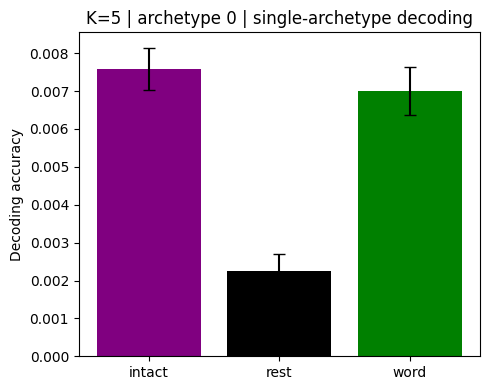

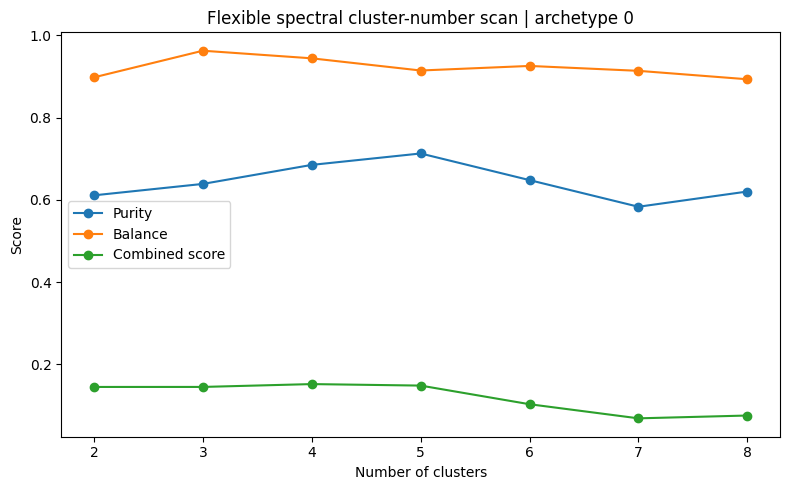

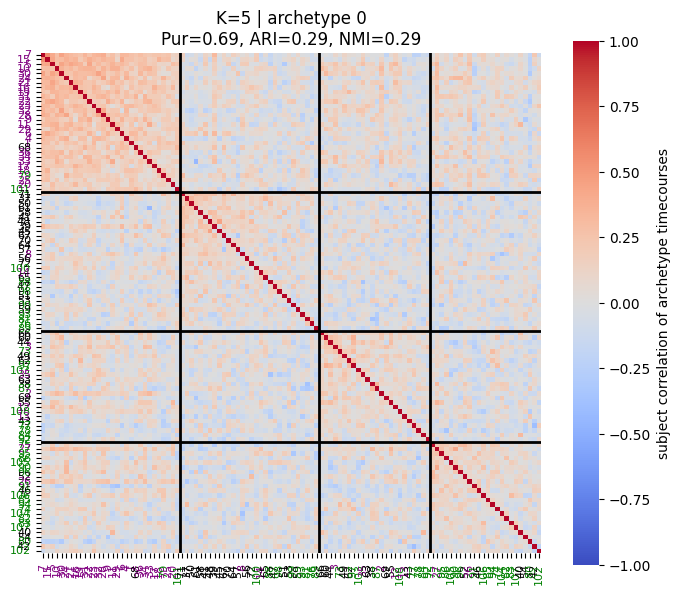

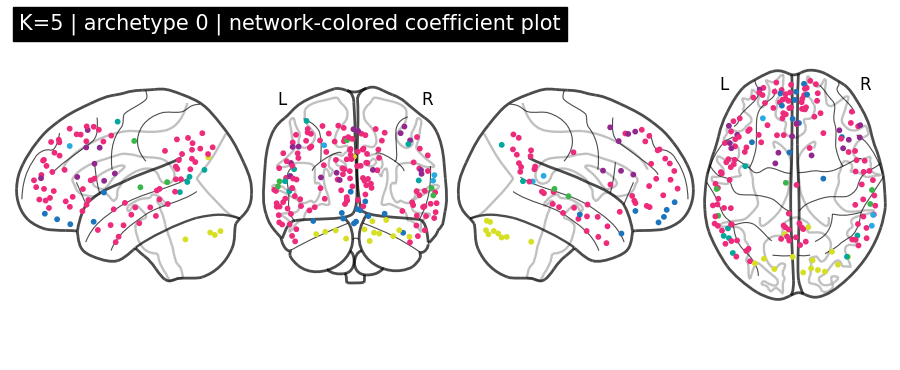

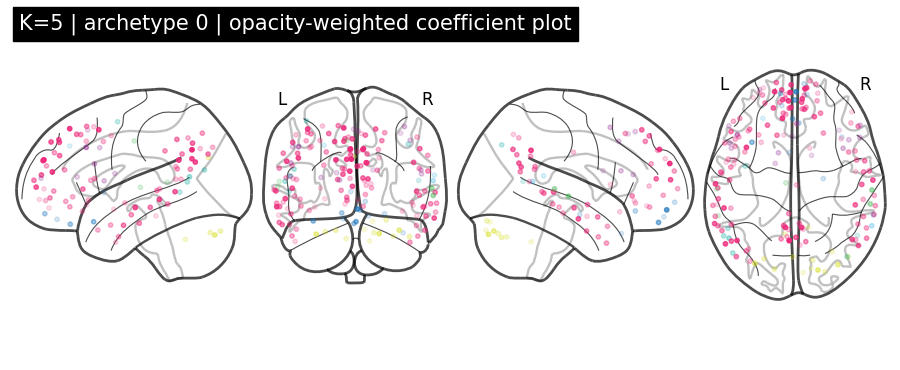

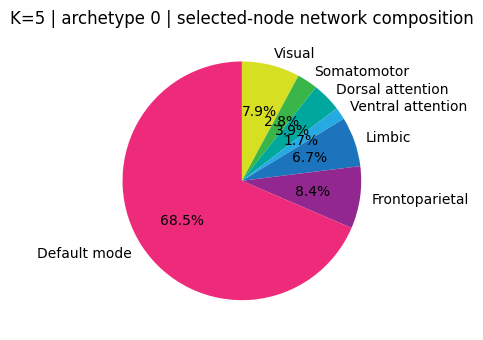


Detailed plots for K=10

K=10 | archetype=3


,K,archetype,best_n_clusters,purity,balance,cluster_score,ari,nmi,cluster_sizes,decode_accuracy_overall,decode_intact,decode_intact_sem,decode_rest,decode_rest_sem,decode_word,decode_word_sem,cluster_rank,decode_rank,joint_rank_score
3,10,3,2,0.62963,0.925926,0.163424,0.430697,0.466848,"[62, 46]",0.006694,0.00875,0.000568,0.00475,0.000532,0.006583,0.000701,2.0,4.0,-6.0


,condition,mean,std,count,sem,archetype
0,intact,0.008750,0.003595,40,0.000568,3
1,rest,0.004750,0.003366,40,0.000532,3
2,word,0.006583,0.004433,40,0.000701,3


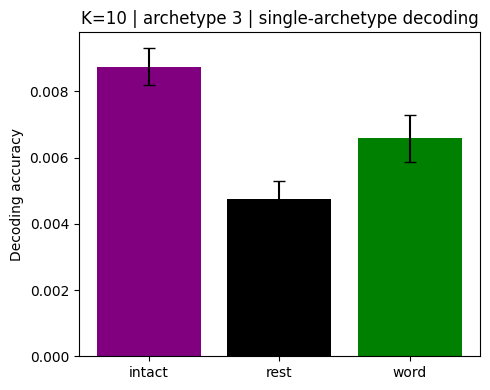

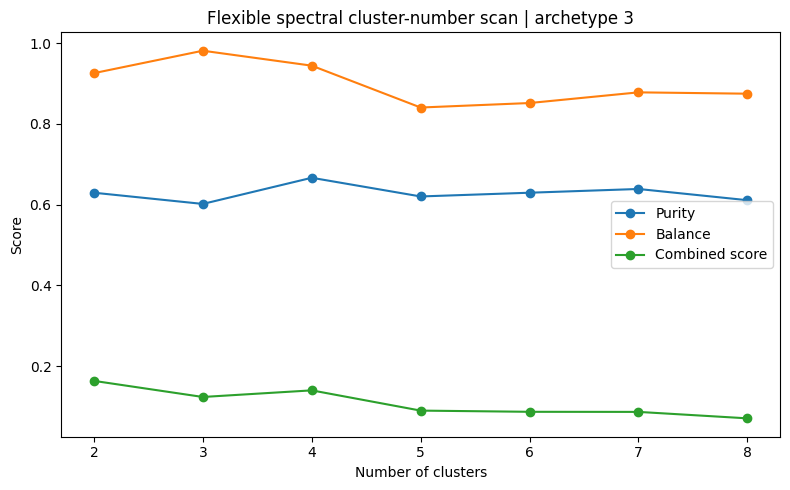

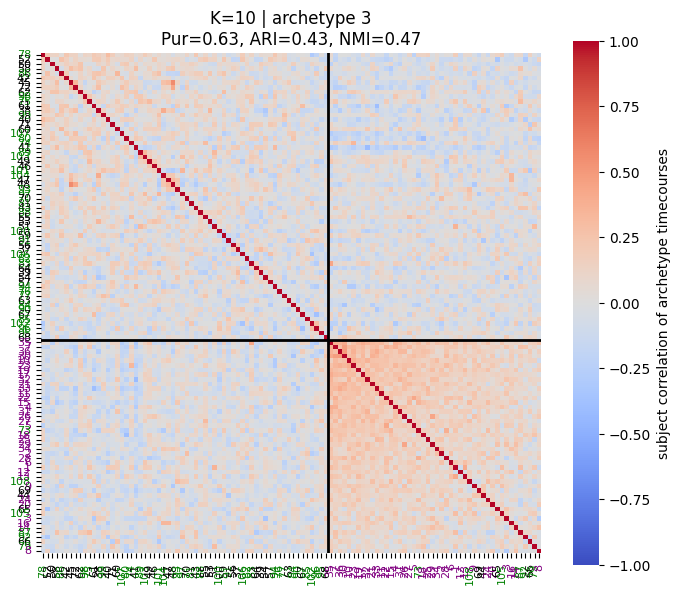

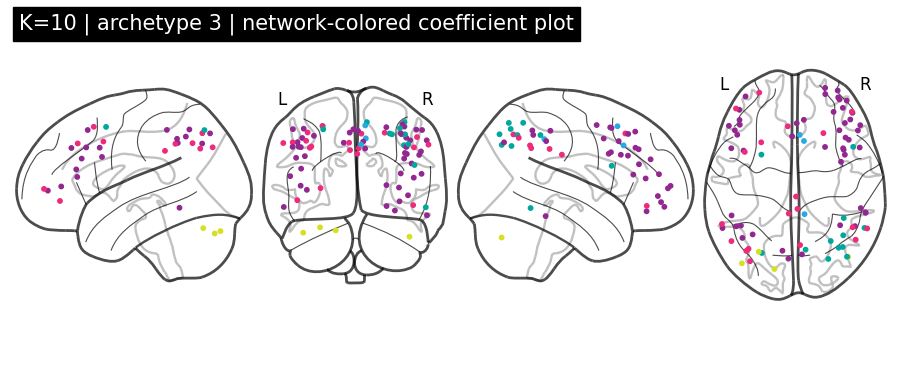

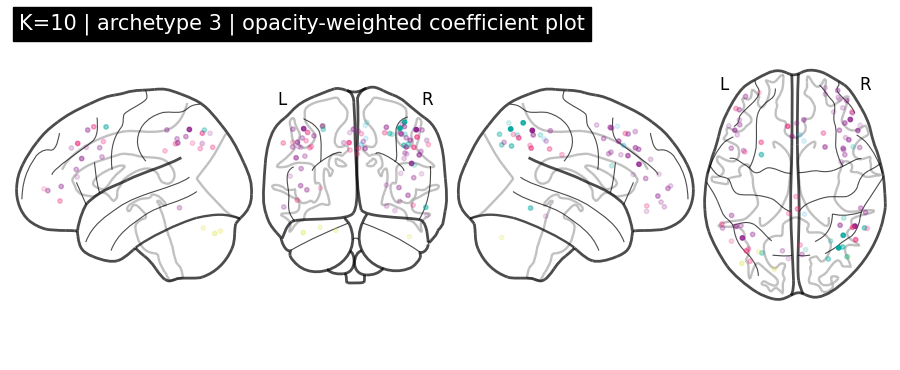

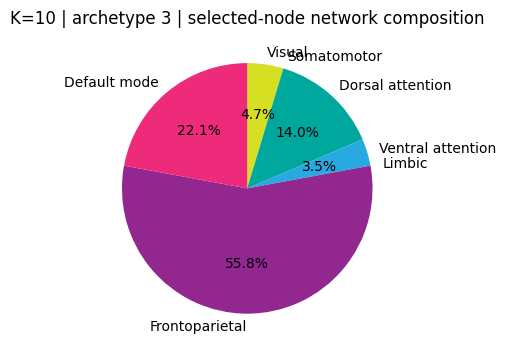


K=10 | archetype=5


,K,archetype,best_n_clusters,purity,balance,cluster_score,ari,nmi,cluster_sizes,decode_accuracy_overall,decode_intact,decode_intact_sem,decode_rest,decode_rest_sem,decode_word,decode_word_sem,cluster_rank,decode_rank,joint_rank_score
5,10,5,2,0.592593,0.972222,0.14306,0.276045,0.272212,"[57, 51]",0.006694,0.0075,0.00053,0.0045,0.000567,0.008083,0.000607,3.0,3.0,-6.0


,condition,mean,std,count,sem,archetype
0,intact,0.007500,0.003355,40,0.000530,5
1,rest,0.004500,0.003585,40,0.000567,5
2,word,0.008083,0.003841,40,0.000607,5


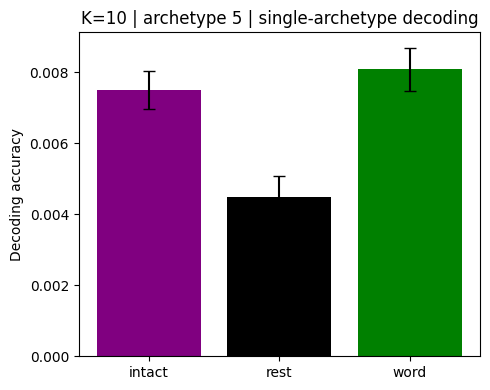

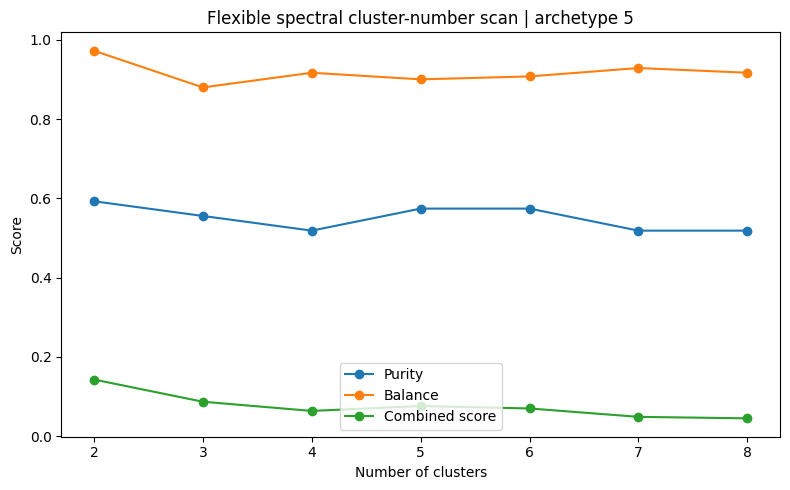

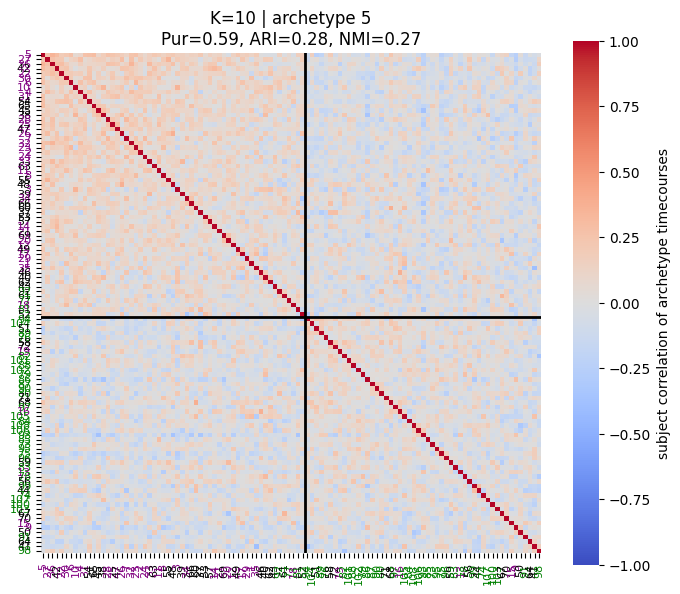

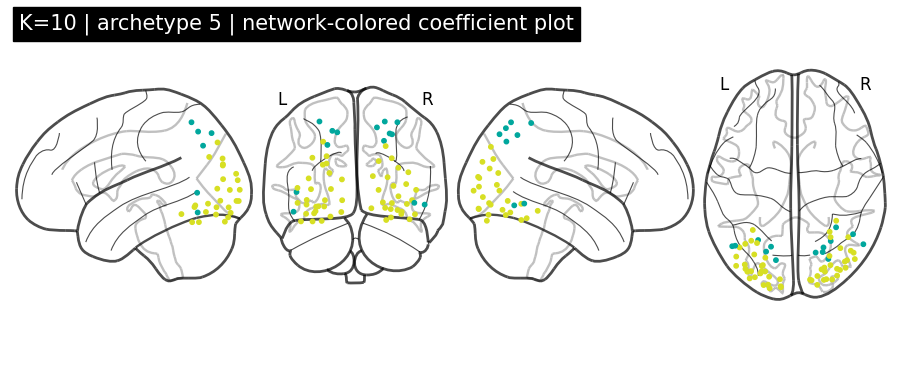

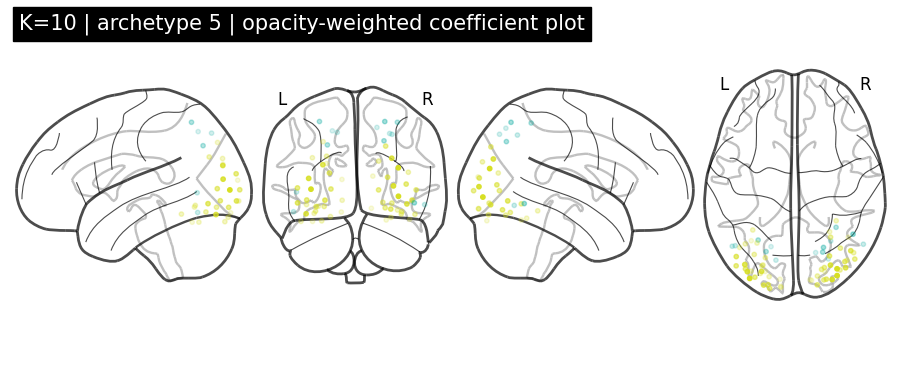

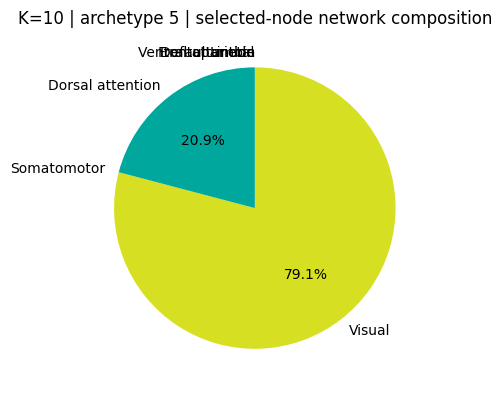


K=10 | archetype=2


,K,archetype,best_n_clusters,purity,balance,cluster_score,ari,nmi,cluster_sizes,decode_accuracy_overall,decode_intact,decode_intact_sem,decode_rest,decode_rest_sem,decode_word,decode_word_sem,cluster_rank,decode_rank,joint_rank_score
2,10,2,2,0.583333,0.990741,0.139058,0.260072,0.261785,"[53, 55]",0.00675,0.007917,0.000502,0.004,0.000575,0.008333,0.000597,4.0,2.0,-6.0


,condition,mean,std,count,sem,archetype
0,intact,0.007917,0.003175,40,0.000502,2
1,rest,0.004000,0.003636,40,0.000575,2
2,word,0.008333,0.003774,40,0.000597,2


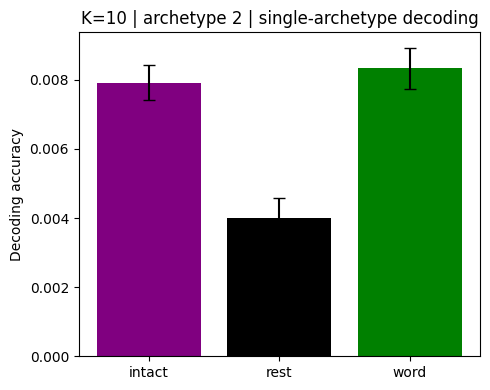

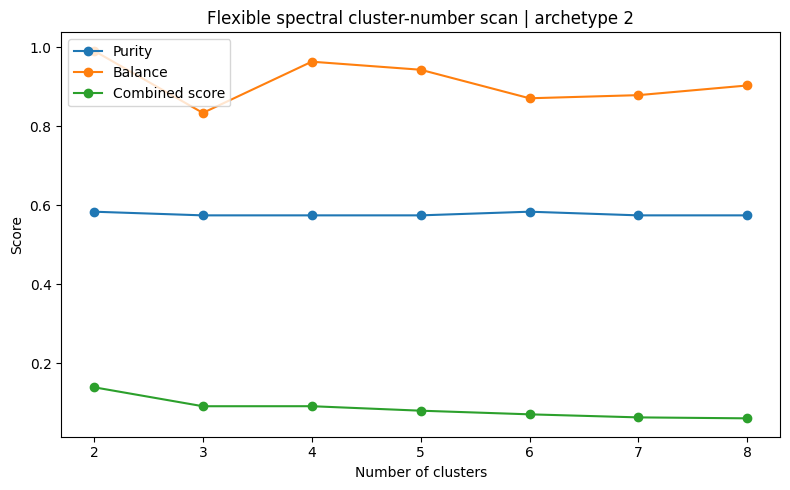

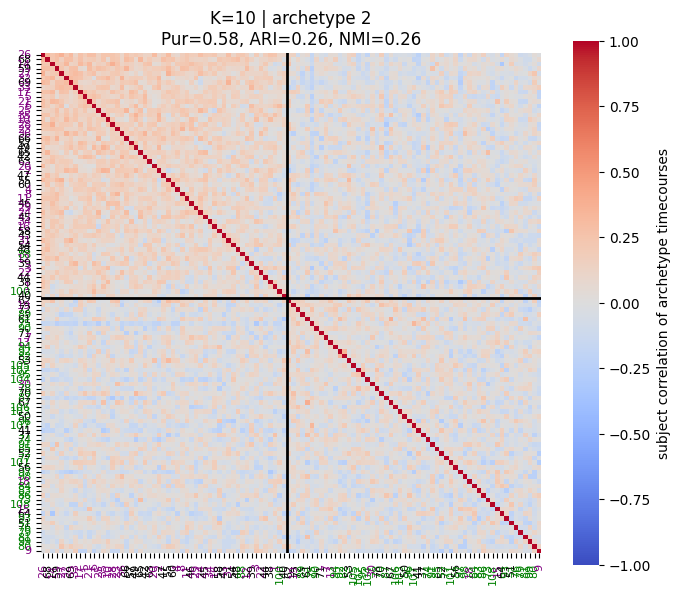

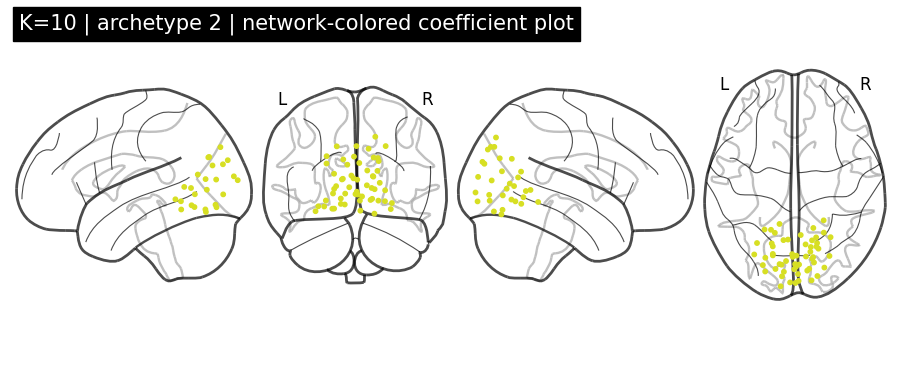

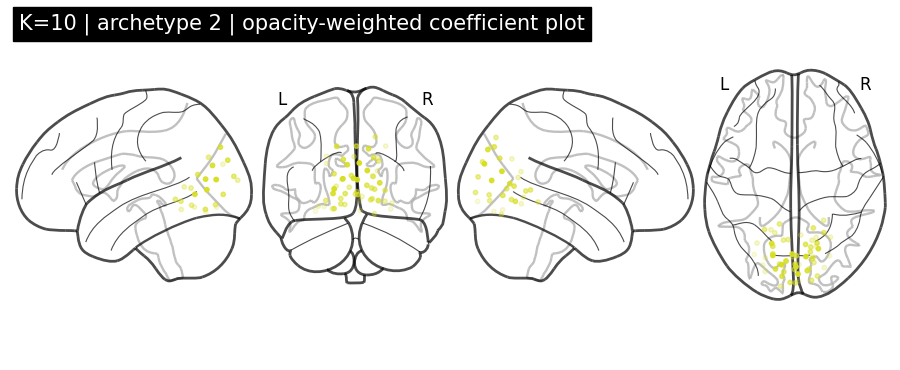

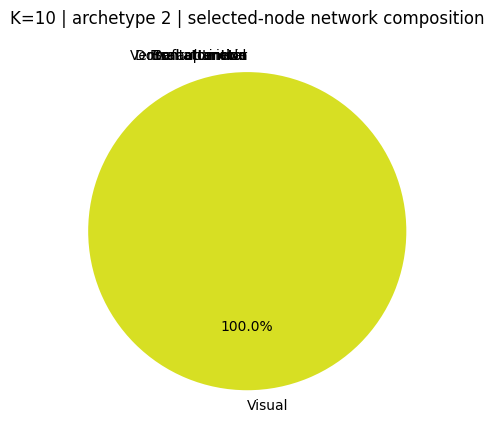

In [23]:

for K in K_VALUES:
    print("\n" + "="*90)
    print(f"Detailed plots for K={K}")
    print("="*90)

    cur = loaded[K]
    results_subj = cur["results_subj"]
    analysis_obj = all_archetype_analysis[K]
    top_df = analysis_obj["summary_df"].sort_values(
        ["joint_rank_score", "cluster_score", "decode_accuracy_overall"],
        ascending=[False, False, False]
    ).head(TOP_N_REPORT)

    for _, row in top_df.iterrows():
        k = int(row["archetype"])
        best_n_clusters = int(row["best_n_clusters"])
        best_cluster_result = analysis_obj["cluster_store"][k]["scan_results"][best_n_clusters]
        dec_summary = analysis_obj["decoding_store"][k]["dec_summary"]

        print(f"\nK={K} | archetype={k}")
        display(row.to_frame().T)
        display(dec_summary)

        plot_decoding_bar_from_summary(dec_summary, K, k)
        plot_cluster_scan_metrics(analysis_obj["cluster_store"][k]["scan_df"], archetype_k=k)
        plot_clustered_similarity(
            best_cluster_result,
            cond_colors=COND_COLORS,
            title=f"K={K} | archetype {k}",
            show_subject_ids=True
        )

        display1, node_codes_local, keep_mask = plot_network_colored_spatial_coeff_map(
            results_subj,
            k,
            title=f"K={K} | archetype {k} | network-colored coefficient plot",
            display_mode="lyrz",
            node_size=10,
            thr_frac=0.30,
            use_opacity=False
        )
        if display1 is not None:
            try:
                display1.close()
            except Exception:
                pass

        display2, node_codes_local2, keep_mask2 = plot_network_colored_spatial_coeff_map(
            results_subj,
            k,
            title=f"K={K} | archetype {k} | opacity-weighted coefficient plot",
            display_mode="lyrz",
            node_size=10,
            thr_frac=0.30,
            use_opacity=True,
            alpha_min=0.15,
            alpha_max=1.0
        )
        if display2 is not None:
            try:
                display2.close()
            except Exception:
                pass

        if node_codes_local is not None and keep_mask is not None:
            plot_network_pie_for_selected_nodes(
                node_codes_local,
                keep_mask,
                title=f"K={K} | archetype {k} | selected-node network composition"
            )


In [24]:

archetype_summary_allK_df.to_csv(
    os.path.join(OUTPUT_DIR, "spatial_across_per_archetype_summary_clean_refactored.csv"),
    index=False
)
best_archetypes_by_K_df.to_csv(
    os.path.join(OUTPUT_DIR, "spatial_across_best_archetypes_by_K_clean_refactored.csv"),
    index=False
)
print("Saved summaries to:", OUTPUT_DIR)


Saved summaries to: postprocess_across_spatial_outputs
